In [61]:
from keras.preprocessing.image import ImageDataGenerator


In [62]:
batch_size= 32


In [63]:
train_datagen= ImageDataGenerator(
    rescale= 1./255
    
)
test_datagen= ImageDataGenerator(rescale= 1./255)

In [64]:
train_generator= train_datagen.flow_from_directory(
    'augmented_images/train',
    target_size=(48,48),
    batch_size= batch_size,
    class_mode='binary',
    shuffle=True)

validation_generator= test_datagen.flow_from_directory(
    'augmented_images/test',
    target_size=(48,48),
    batch_size= batch_size,
    class_mode='binary')
    


Found 16162 images belonging to 2 classes.
Found 7615 images belonging to 2 classes.


In [65]:
len(train_generator)

506

In [66]:
import tensorflow
from tensorflow import keras
from keras.layers import Conv2D,Dense,Dropout,MaxPooling2D, AveragePooling2D, Flatten, BatchNormalization
from keras.models import Sequential

In [117]:

model = Sequential()
model.add(Conv2D(64,kernel_size= (3,3),activation='relu' , strides= 1,input_shape=(48,48,3),padding='same'))
model.add(Conv2D(64,kernel_size= (3,3), activation='relu', strides=1))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2))
model.add(Dropout(0.3))



model.add(Flatten())

model.add(Dense(8,activation='relu', kernel_regularizer= l2(0.0001)))
model.add(Dropout(0.5))
model.add(Dense(1, activation= 'sigmoid'))

# Compile
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_27"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_95 (Conv2D)           (None, 48, 48, 64)        1792      
_________________________________________________________________
conv2d_96 (Conv2D)           (None, 46, 46, 64)        36928     
_________________________________________________________________
batch_normalization_29 (Batc (None, 46, 46, 64)        256       
_________________________________________________________________
max_pooling2d_46 (MaxPooling (None, 23, 23, 64)        0         
_________________________________________________________________
dropout_57 (Dropout)         (None, 23, 23, 64)        0         
_________________________________________________________________
flatten_27 (Flatten)         (None, 33856)             0         
_________________________________________________________________
dense_52 (Dense)             (None, 8)               

In [118]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    filepath='best_model_5.h5',       # or 'checkpoints/best_model.keras'
    monitor='val_accuracy',             # or 'val_accuracy'
    save_best_only=True,
    save_weights_only=False,
    mode='max',                     # 'min' for loss, 'max' for accuracy
    verbose=1
)

In [119]:
history= model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    shuffle =True,
    callbacks= [checkpoint_cb]
   
)

Epoch 1/5
506/506 [==============================] - 11s 21ms/step - loss: 0.2993 - accuracy: 0.8367 - val_loss: 0.2592 - val_accuracy: 0.8758

Epoch 00001: val_accuracy improved from -inf to 0.87577, saving model to best_model_5.h5
Epoch 2/5
506/506 [==============================] - 10s 20ms/step - loss: 0.1125 - accuracy: 0.9407 - val_loss: 0.3829 - val_accuracy: 0.8758

Epoch 00002: val_accuracy did not improve from 0.87577
Epoch 3/5
506/506 [==============================] - 10s 20ms/step - loss: 0.0598 - accuracy: 0.9566 - val_loss: 1.0009 - val_accuracy: 0.8758

Epoch 00003: val_accuracy did not improve from 0.87577
Epoch 4/5
506/506 [==============================] - 10s 21ms/step - loss: 0.0515 - accuracy: 0.9587 - val_loss: 1.2435 - val_accuracy: 0.8758

Epoch 00004: val_accuracy did not improve from 0.87577
Epoch 5/5
506/506 [==============================] - 10s 20ms/step - loss: 0.0466 - accuracy: 0.9667 - val_loss: 1.6846 - val_accuracy: 0.7514

Epoch 00005: val_accuracy 

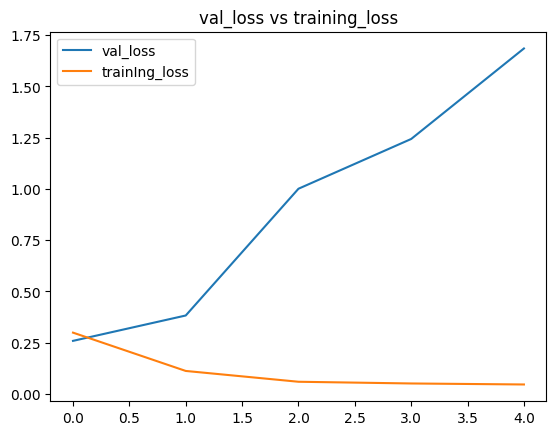

In [120]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['loss'], label='trainIng_loss')
plt.legend()
plt.title('val_loss vs training_loss')
plt.show()

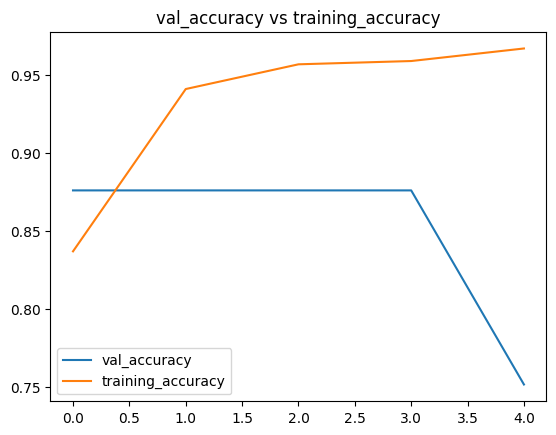

In [121]:
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'], label='training_accuracy')
plt.legend()
plt.title('val_accuracy vs training_accuracy')
plt.show()

In [17]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 32, 32, 32)        896       
_________________________________________________________________
batch_normalization_3 (Batch (None, 32, 32, 32)        128       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 16, 16, 64)        18496     
_________________________________________________________________
batch_normalization_4 (Batch (None, 16, 16, 64)        256       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 8, 8, 64)          0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 8, 8, 128)        

In [18]:
history= model.fit_generator(
    train_generator,
    epochs=100,
    validation_data= validation_generator,
    shuffle=True
    
)

Epoch 1/100
80/80 [==============================] - 21s 257ms/step - loss: 0.5487 - accuracy: 0.8045 - val_loss: 2.1612 - val_accuracy: 0.4975
Epoch 2/100
80/80 [==============================] - 1s 18ms/step - loss: 0.0877 - accuracy: 0.9670 - val_loss: 6.2606 - val_accuracy: 0.4975
Epoch 3/100
80/80 [==============================] - 2s 20ms/step - loss: 0.0243 - accuracy: 0.9937 - val_loss: 7.1748 - val_accuracy: 0.4975
Epoch 4/100
80/80 [==============================] - 1s 17ms/step - loss: 0.0179 - accuracy: 0.9925 - val_loss: 7.8922 - val_accuracy: 0.4975
Epoch 5/100
80/80 [==============================] - 1s 18ms/step - loss: 0.0296 - accuracy: 0.9902 - val_loss: 4.0818 - val_accuracy: 0.4975
Epoch 6/100
80/80 [==============================] - 2s 19ms/step - loss: 0.0326 - accuracy: 0.9882 - val_loss: 0.5154 - val_accuracy: 0.7492
Epoch 7/100
80/80 [==============================] - 1s 18ms/step - loss: 0.0084 - accuracy: 0.9976 - val_loss: 2.3824 - val_accuracy: 0.6233
Epoc

In [19]:
import matplotlib.pyplot as plt

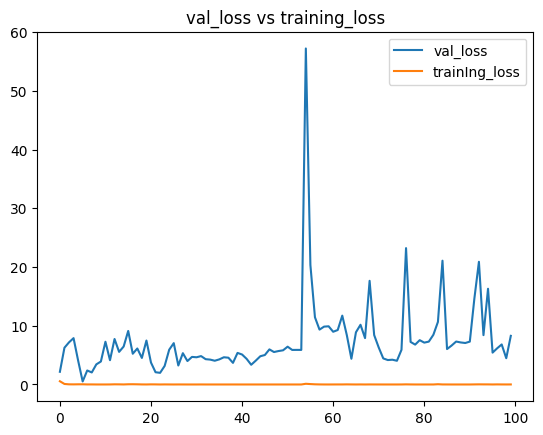

In [20]:
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['loss'], label='trainIng_loss')
plt.legend()
plt.title('val_loss vs training_loss')
plt.show()

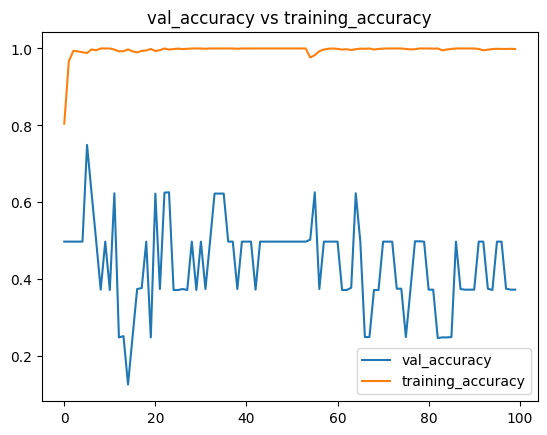

In [21]:
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'], label='training_accuracy')
plt.legend()
plt.title('val_accuracy vs training_accuracy')
plt.show()

In [13]:
max(history.history['val_accuracy'])

0.875

In [14]:
type(history.history)
import pandas as pd

In [15]:
df= pd.DataFrame(history.history)

In [16]:
df[df['val_accuracy']==max(history.history['val_accuracy'])]

,loss,accuracy,val_loss,val_accuracy
12,0.031825,0.988453,0.631723,0.875
15,0.004668,1.000000,0.606725,0.875
16,0.014213,0.994226,0.417752,0.875


In [17]:
df.loc[92]

loss            0.001701
accuracy        1.000000
val_loss        7.914650
val_accuracy    0.500000
Name: 92, dtype: float64

In [18]:
df.loc[92:]

,loss,accuracy,val_loss,val_accuracy
92,0.001701,1.000000,7.914650,0.500
93,0.006235,0.996536,4.915775,0.500
94,0.001422,1.000000,4.699493,0.750
95,0.005567,0.997691,4.928463,0.750
96,0.218905,0.960739,3.603596,0.750
97,0.041542,0.988453,7.171661,0.625
98,0.028891,0.994226,4.939106,0.750
99,0.106667,0.958430,4.178291,0.375


ALEXNET



In [49]:
batch_size=32
train_datagen= ImageDataGenerator(
    rescale= 1./255
    
)
test_datagen= ImageDataGenerator(rescale= 1./255)

train_generator= train_datagen.flow_from_directory(
    'augmented_images/train',
    target_size=(128,128),
    batch_size= batch_size,
    class_mode='binary')

validation_generator= test_datagen.flow_from_directory(
    'augmented_images/test',
    target_size=(128,128),
    batch_size= batch_size,
    class_mode='binary')
    


Found 356 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


In [50]:
model= Sequential()
#Conv1
model.add(Conv2D(96,kernel_size=(9,9),strides=4,activation='relu',input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(3,3), strides=2,padding='valid'))


#Conv2
model.add(Conv2D(256,kernel_size=(5,5),activation='relu',padding='same'))

model.add(MaxPooling2D(pool_size=(3,3), strides=2))

#Conv3
model.add(Conv2D(384,kernel_size=(3,3),activation='relu',padding='same'))

#Conv4
model.add(Conv2D(384,kernel_size=(3,3),activation='relu',padding='same'))




#Conv5
model.add(Conv2D(256,kernel_size=(3,3),activation='relu',padding='same'))

model.add(MaxPooling2D(pool_size=(3,3), strides=2))


model.add(Flatten())


model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [51]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_22 (Conv2D)           (None, 30, 30, 96)        23424     
_________________________________________________________________
max_pooling2d_18 (MaxPooling (None, 14, 14, 96)        0         
_________________________________________________________________
conv2d_23 (Conv2D)           (None, 14, 14, 256)       614656    
_________________________________________________________________
max_pooling2d_19 (MaxPooling (None, 6, 6, 256)         0         
_________________________________________________________________
conv2d_24 (Conv2D)           (None, 6, 6, 384)         885120    
_________________________________________________________________
conv2d_25 (Conv2D)           (None, 6, 6, 384)         1327488   
_________________________________________________________________
conv2d_26 (Conv2D)           (None, 6, 6, 256)        

In [52]:
from tensorflow.keras.optimizers import Adam


optimizer = Adam(learning_rate=0.0001)  

In [53]:
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_accuracy', patience=10)


In [55]:
history= model.fit(
    train_generator,
    epochs=100,
    validation_data= validation_generator,
    shuffle=True,
    
    
)

Epoch 1/100
12/12 [==============================] - 4s 245ms/step - loss: 0.6922 - accuracy: 0.5197 - val_loss: 0.6936 - val_accuracy: 0.4970
Epoch 2/100
12/12 [==============================] - 0s 30ms/step - loss: 0.6946 - accuracy: 0.5197 - val_loss: 0.6937 - val_accuracy: 0.4970
Epoch 3/100
12/12 [==============================] - 0s 31ms/step - loss: 0.6910 - accuracy: 0.5253 - val_loss: 0.6955 - val_accuracy: 0.4970
Epoch 4/100
12/12 [==============================] - 0s 31ms/step - loss: 0.6889 - accuracy: 0.5281 - val_loss: 0.6948 - val_accuracy: 0.4970
Epoch 5/100
12/12 [==============================] - 0s 30ms/step - loss: 0.6885 - accuracy: 0.5281 - val_loss: 0.7080 - val_accuracy: 0.4970
Epoch 6/100
12/12 [==============================] - 0s 30ms/step - loss: 0.6830 - accuracy: 0.5281 - val_loss: 0.7014 - val_accuracy: 0.4970
Epoch 7/100
12/12 [==============================] - 0s 31ms/step - loss: 0.6732 - accuracy: 0.5421 - val_loss: 0.6972 - val_accuracy: 0.3772
Epoch

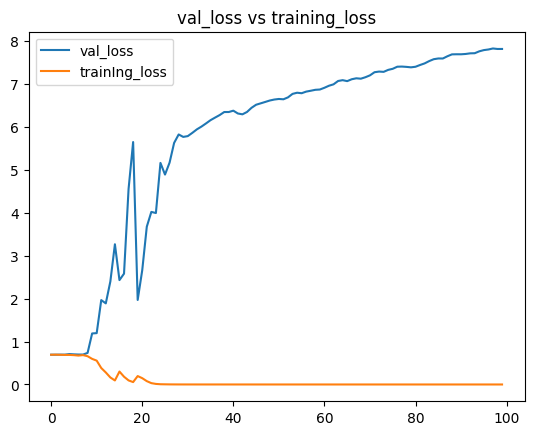

In [56]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['loss'], label='trainIng_loss')
plt.legend()
plt.title('val_loss vs training_loss')
plt.show()

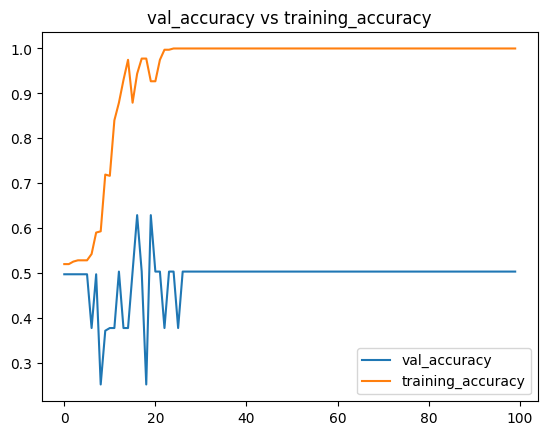

In [57]:
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'], label='training_accuracy')
plt.legend()
plt.title('val_accuracy vs training_accuracy')
plt.show()

In [58]:
# Initialize the model
model = Sequential()

# Input Layer + Conv Block 1
model.add(Conv2D(32, (3, 3), activation='relu', padding='same',input_shape=(128, 128, 3))) 
model.add(BatchNormalization())# or (224, 224, 3)
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv Block 2
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv Block 3
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flattening
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
# Output Layer (2 classes => binary classification)
model.add(Dense(1, activation='sigmoid'))  # sigmoid for binary

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [59]:
history= model.fit(
    train_generator,
    epochs=30,
    validation_data= validation_generator,
    shuffle=True,
    
    
)

Epoch 1/30
12/12 [==============================] - 2s 74ms/step - loss: 1.1757 - accuracy: 0.5478 - val_loss: 0.7170 - val_accuracy: 0.2455
Epoch 2/30
12/12 [==============================] - 0s 36ms/step - loss: 1.0941 - accuracy: 0.5758 - val_loss: 0.7186 - val_accuracy: 0.2455
Epoch 3/30
12/12 [==============================] - 0s 36ms/step - loss: 0.8183 - accuracy: 0.6742 - val_loss: 0.7307 - val_accuracy: 0.4970
Epoch 4/30
12/12 [==============================] - 0s 36ms/step - loss: 0.6335 - accuracy: 0.7191 - val_loss: 0.7169 - val_accuracy: 0.4970
Epoch 5/30
12/12 [==============================] - 0s 36ms/step - loss: 0.5140 - accuracy: 0.7528 - val_loss: 0.7244 - val_accuracy: 0.5030
Epoch 6/30
12/12 [==============================] - 0s 38ms/step - loss: 0.5325 - accuracy: 0.7612 - val_loss: 0.7257 - val_accuracy: 0.5030
Epoch 7/30
12/12 [==============================] - 0s 36ms/step - loss: 0.4436 - accuracy: 0.7753 - val_loss: 0.7621 - val_accuracy: 0.5030
Epoch 8/30
12

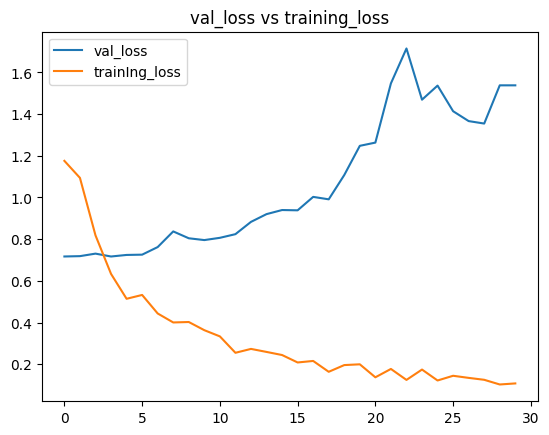

In [60]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_loss'],label='val_loss')
plt.plot(history.history['loss'], label='trainIng_loss')
plt.legend()
plt.title('val_loss vs training_loss')
plt.show()

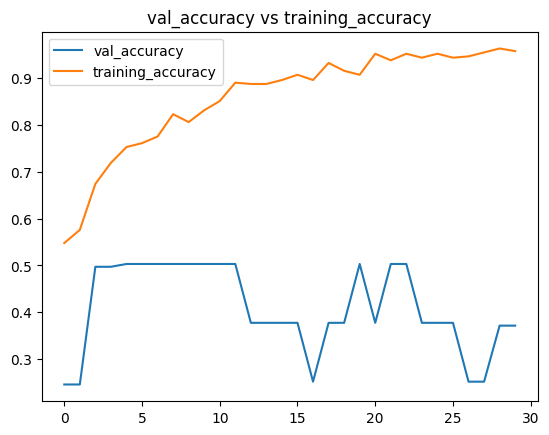

In [61]:
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.plot(history.history['accuracy'], label='training_accuracy')
plt.legend()
plt.title('val_accuracy vs training_accuracy')
plt.show()